In [24]:
# Load Data

import kagglehub
 
# Download latest version

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
 
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud


In [25]:
# Import necessary Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pydotplus
from IPython.display import Image
from matplotlib import rcParams
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [26]:
# Read Data

Data = pd.read_csv(r"/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

# Display Data

Data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
Data = Data.drop(["Time"], axis=1)

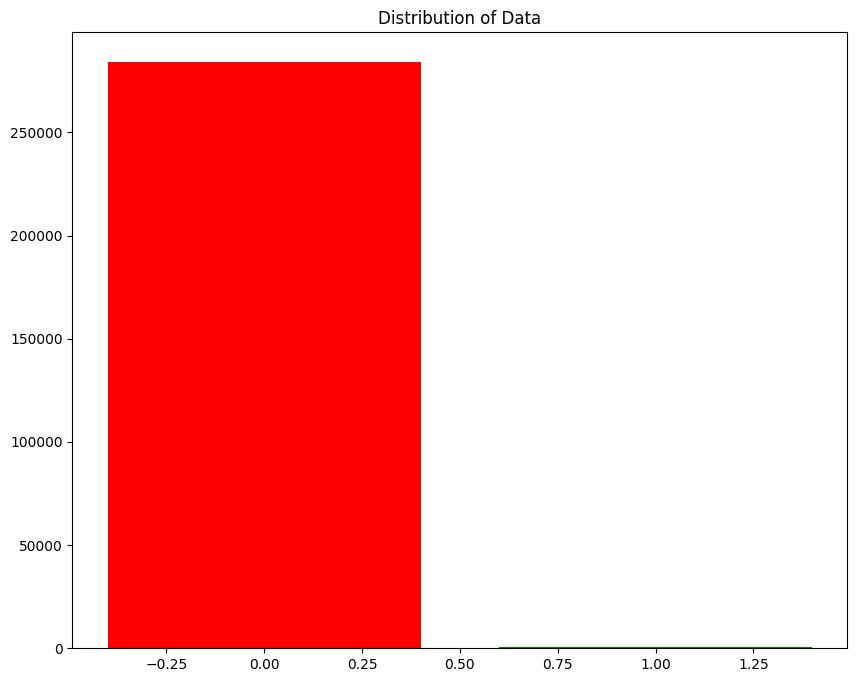

In [28]:
rcParams['figure.figsize'] = 10, 8
plt.bar(Data['Class'].unique(), Data['Class'].value_counts(),color=['red','green'])
plt.title("Distribution of Data")
plt.show()

In [29]:
X = Data.drop("Class", axis=1)
Y = Data["Class"]

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [30]:
HP = {"criterion": ["gini", "entropy"], "max_depth": [1, 2, 3, 4, 5, 10, 15, 20]}

Tree = GridSearchCV(DecisionTreeClassifier(), param_grid=HP, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)
Tree.fit(x_train, y_train)

print("The best Parameter combined is: ", Tree.best_params_)
print("The best Score combined is: ", Tree.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
The best Parameter combined is:  {'criterion': 'entropy', 'max_depth': 4}
The best Score combined is:  0.93706791416122


In [31]:
y_pred = Tree.predict(x_test)

In [32]:
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))
 
#Calculate sensitivity and specificity
 
total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)
 
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )
 
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56852    12]
 [   19    79]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.87      0.81      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9994557775359011
Sensitivity :  0.9997889701744513
Specificity :  0.8061224489795918


In [33]:
# pip install graphviz

In [34]:
from sklearn.tree import export_graphviz
from sklearn import tree
import graphviz

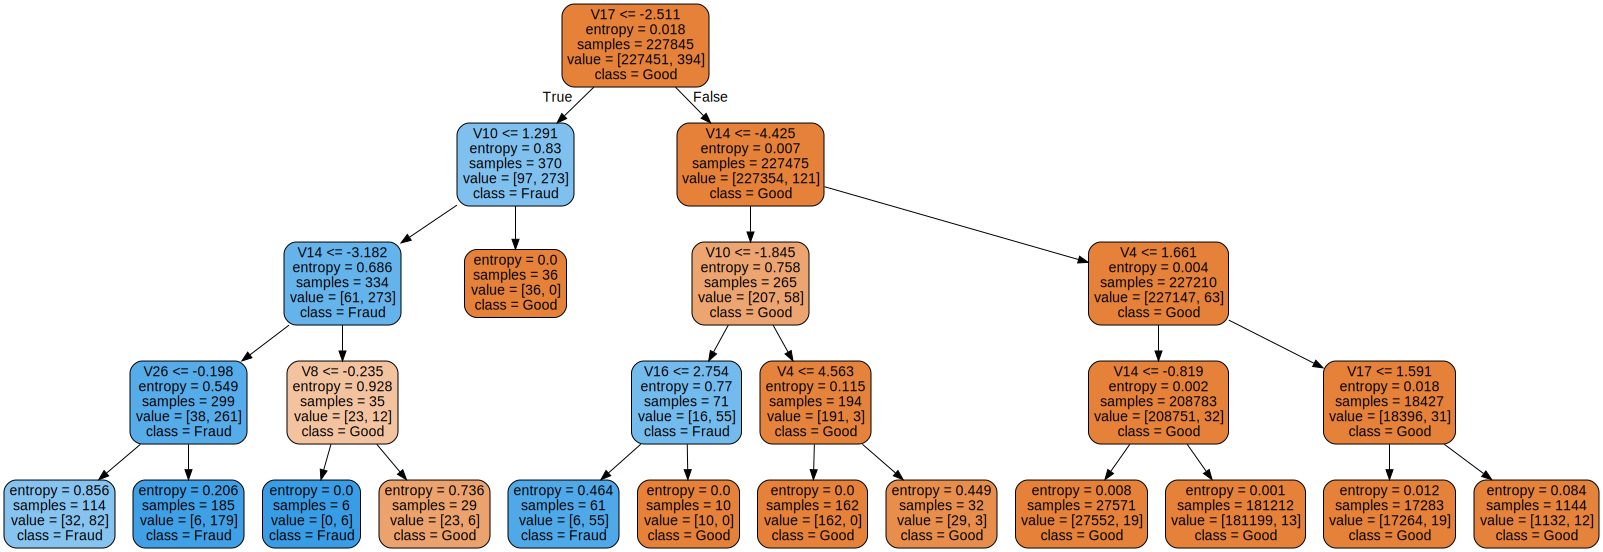

In [35]:
best_model = Tree.best_estimator_
 
dot_data = export_graphviz(best_model, out_file=None, feature_names=x_train.columns, class_names=["Good", "Fraud"], filled=True, rounded=True)
 
graph = graphviz.Source(dot_data)
graph

In [36]:
HP_Bagging = {"n_estimators": [1, 2, 3, 4, 5, 6]}

Bag_Tree = GridSearchCV(BaggingClassifier(), param_grid=HP_Bagging, scoring='roc_auc', n_jobs=-1, cv=5, verbose=2)

Bag_Tree.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5, estimator=BaggingClassifier(), n_jobs=-1,
             param_grid={'n_estimators': [1, 2, 3, 4, 5, 6]}, scoring='roc_auc',
             verbose=2)

In [37]:
print("The best Parameter combined is: ", Bag_Tree.best_params_)
print("The best Score combined is: ", Bag_Tree.best_score_)

best_model = Bag_Tree.best_estimator_

The best Parameter combined is:  {'n_estimators': 6}
The best Score combined is:  0.9211405541921742


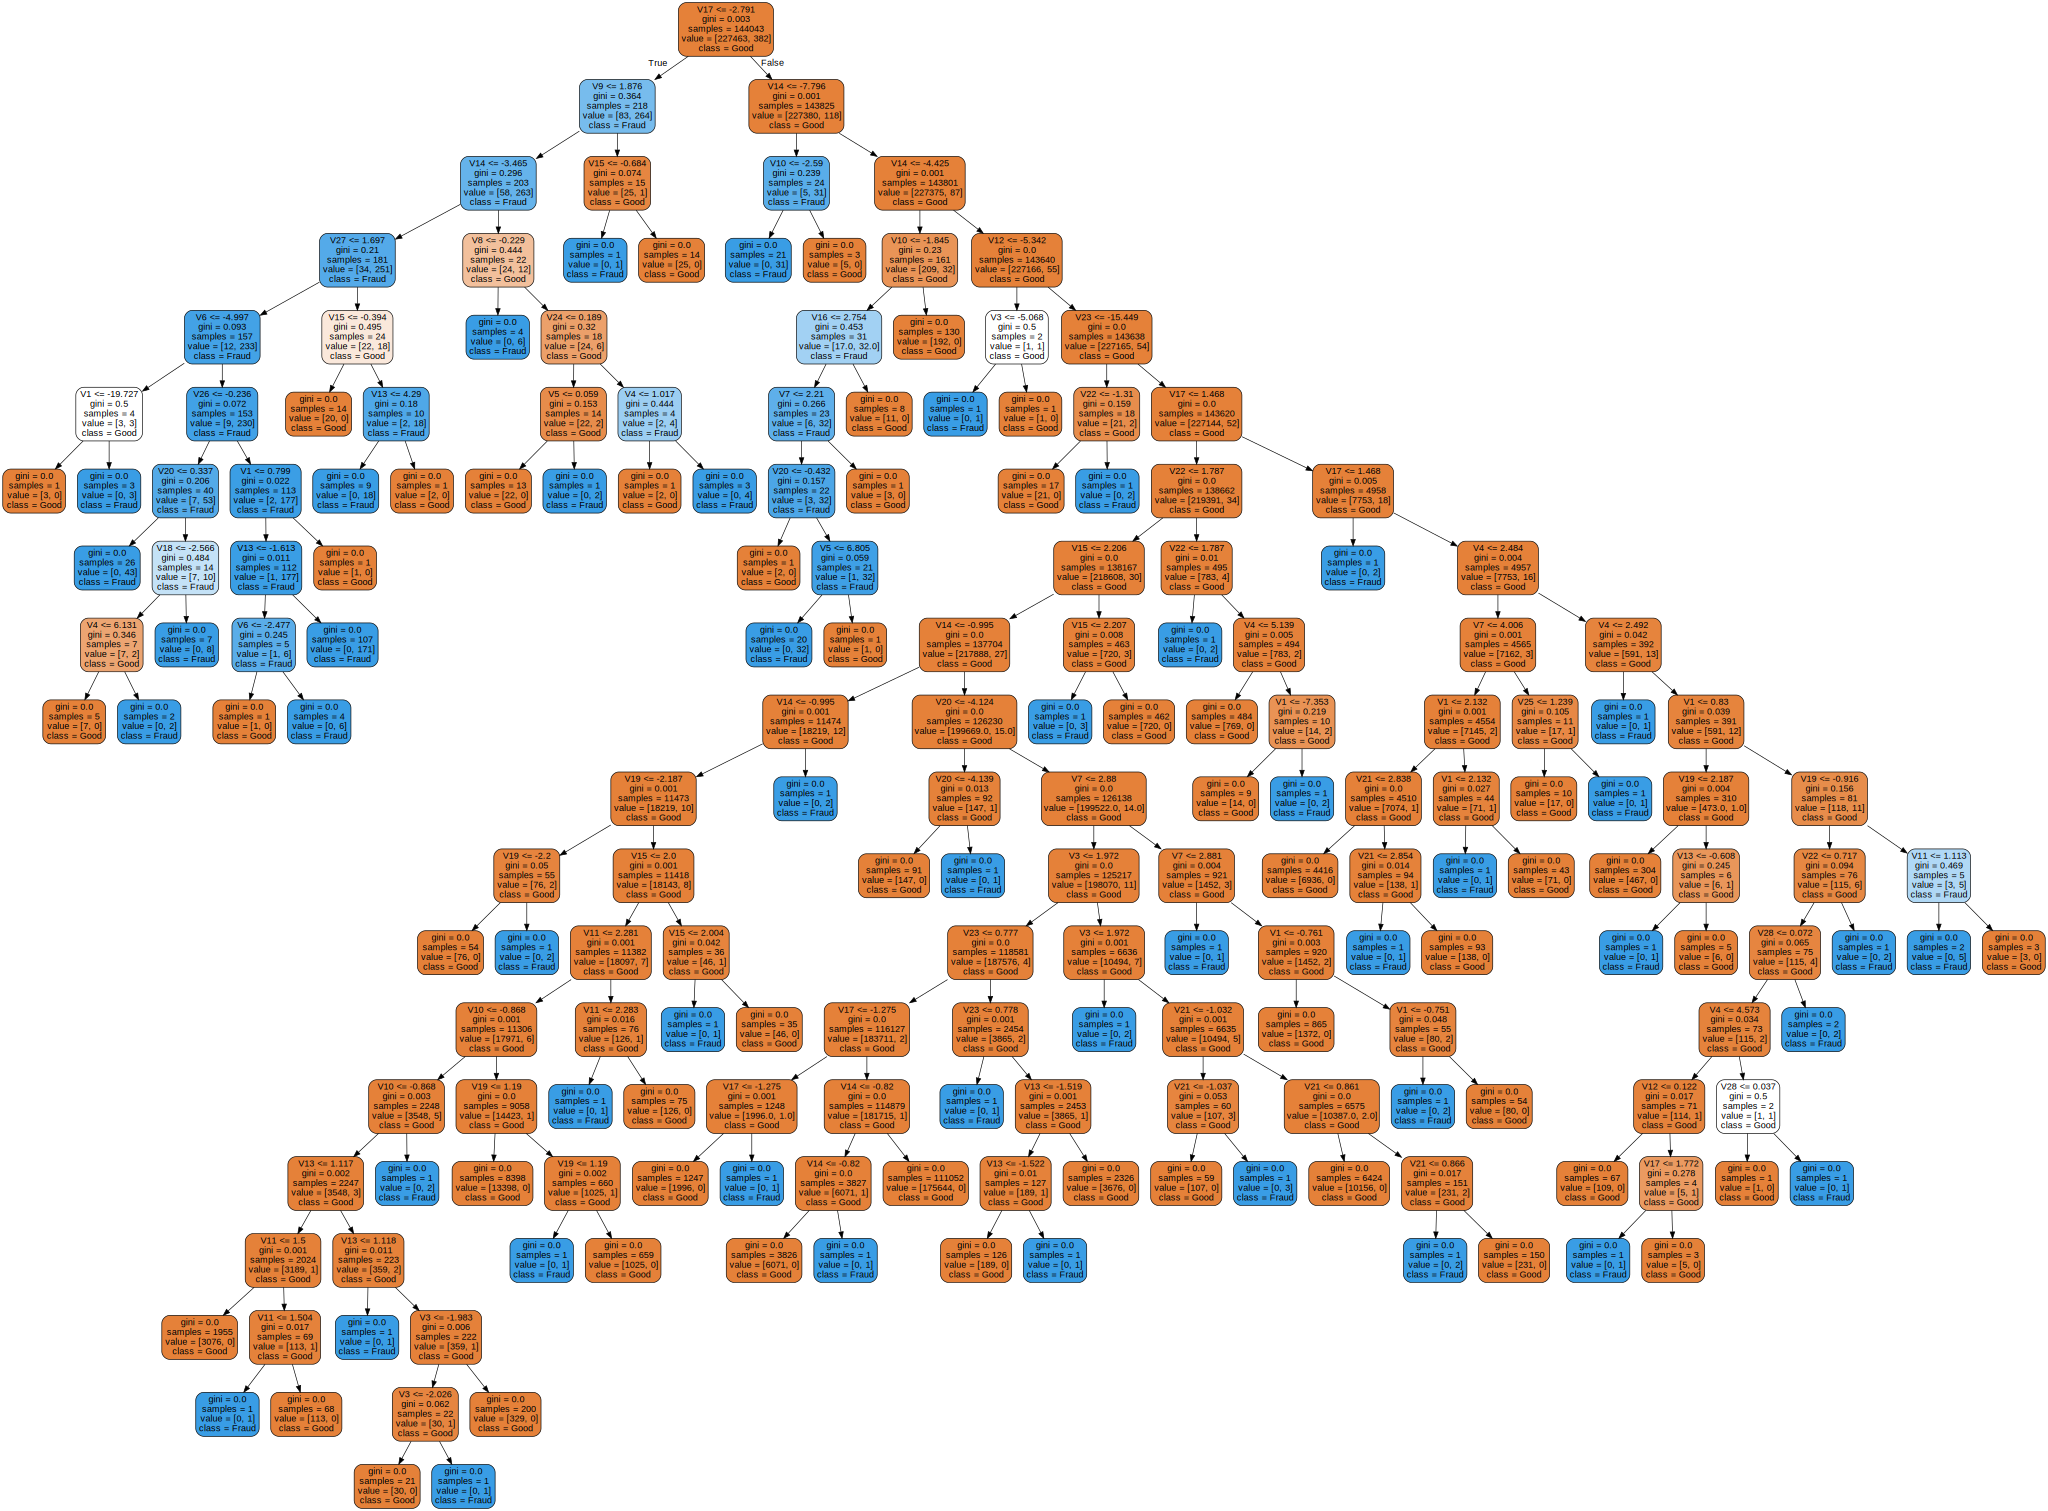

In [38]:
single_tree = best_model.estimators_[0]

dot_data = export_graphviz(single_tree, out_file=None, feature_names=x_train.columns, class_names=["Good", "Fraud"], filled=True, rounded=True)

graph = graphviz.Source(dot_data)
graph

In [39]:
HP_RF={'criterion':['entropy'],'max_depth':[4,10],'n_estimators':[50, 100], 'max_features':['sqrt']}
      
RF_Tree = GridSearchCV(RandomForestClassifier(), param_grid=HP_RF, scoring='roc_auc', n_jobs=-1, cv=5, verbose=2)

RF_Tree.fit(x_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy'], 'max_depth': [4, 10],
                         'max_features': ['sqrt'], 'n_estimators': [50, 100]},
             scoring='roc_auc', verbose=2)

In [40]:
print("The best Parameter combined is: ", RF_Tree.best_params_)
print("The best Score combined is: ", RF_Tree.best_score_)

best_model = RF_Tree.best_estimator_

The best Parameter combined is:  {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
The best Score combined is:  0.9798344160384314


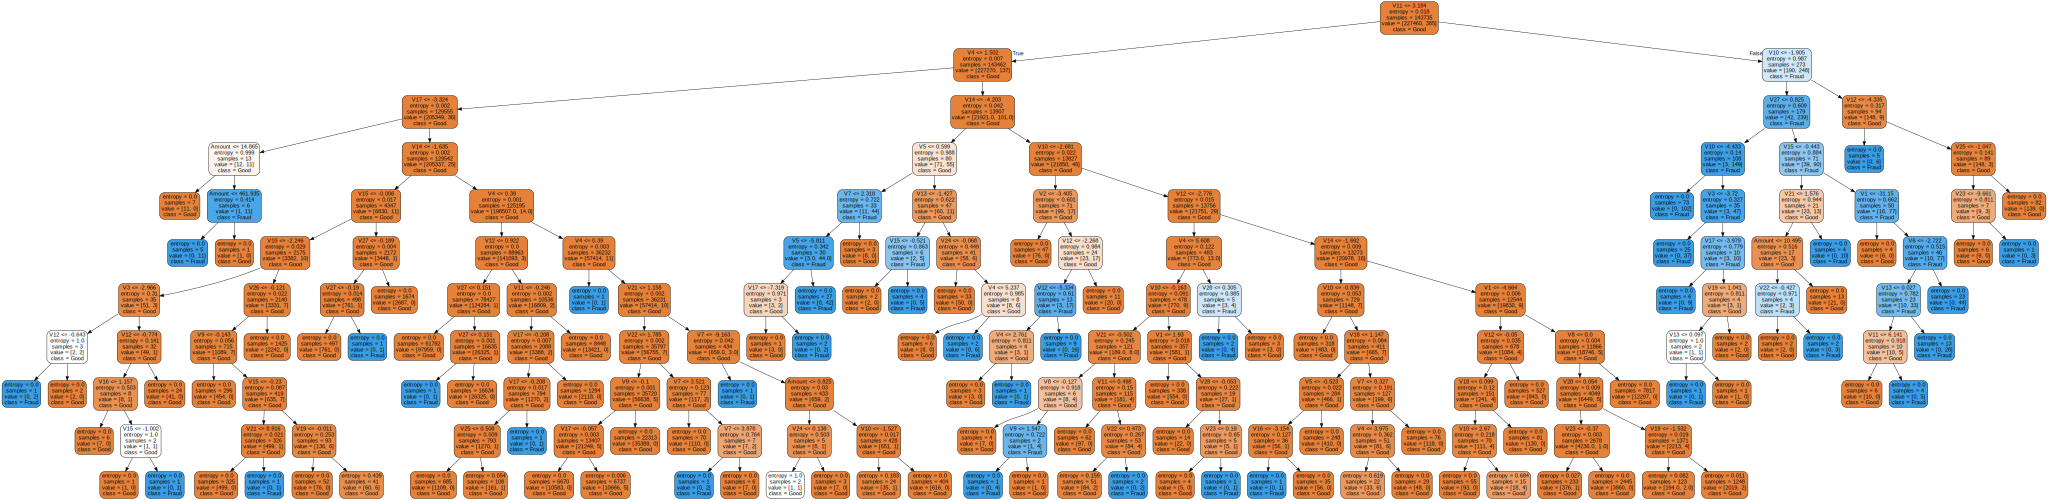

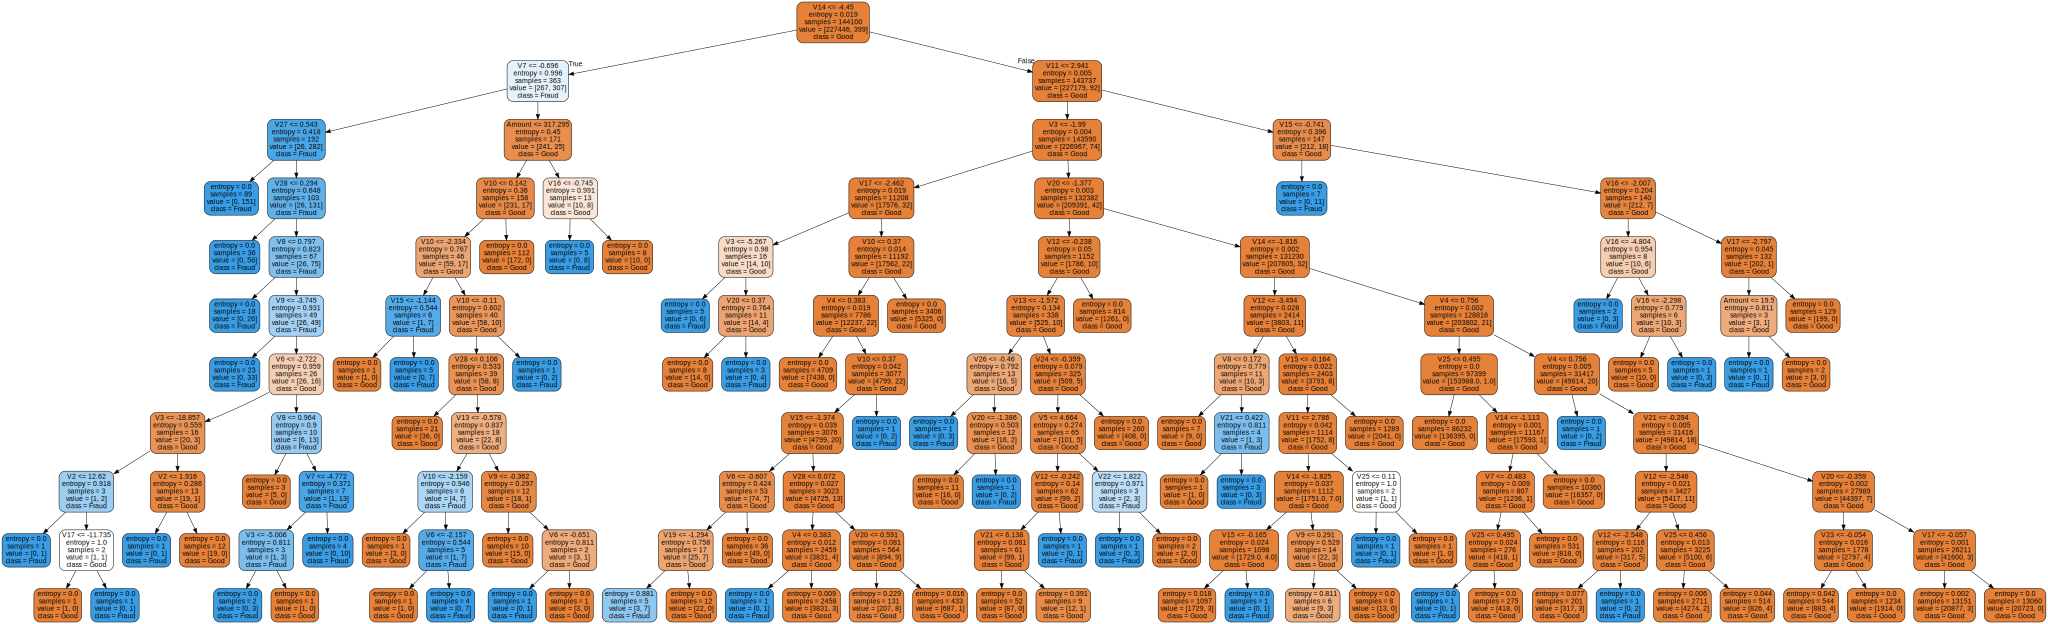

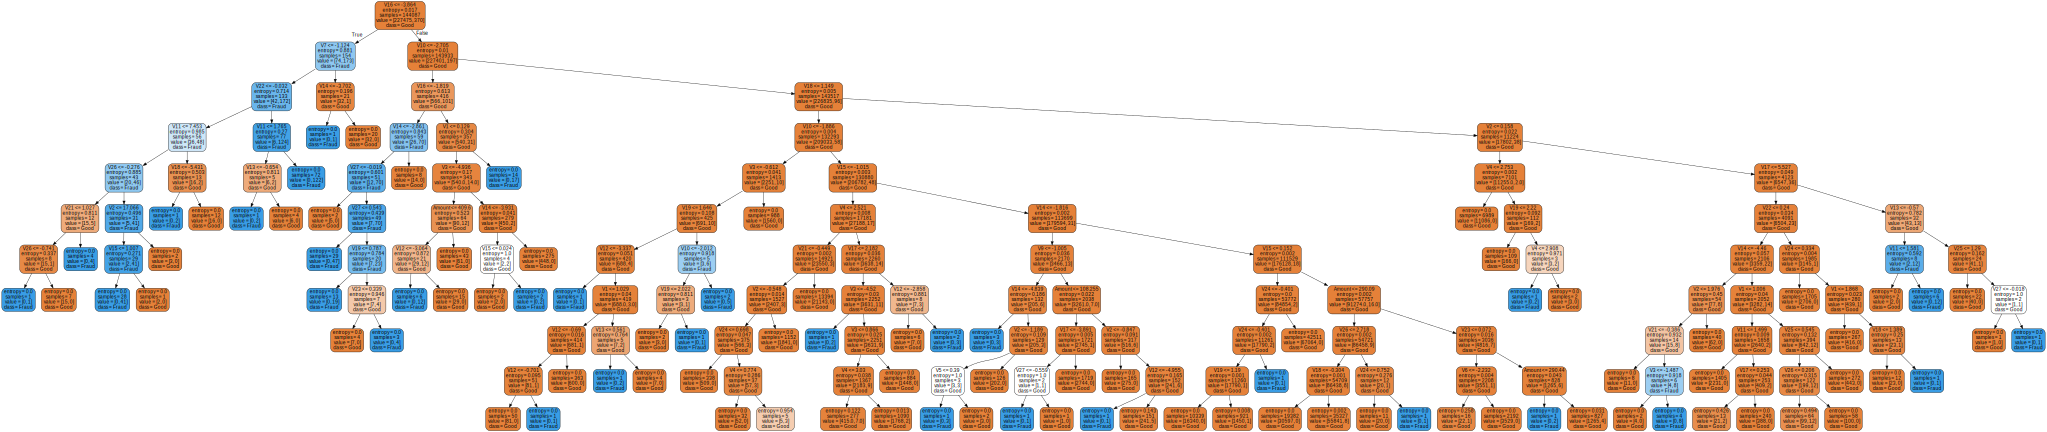

In [43]:
for i, tree_in_forest in enumerate(best_model.estimators_[:3]):
    dot_data = export_graphviz(tree_in_forest, out_file=None, feature_names=x_train.columns, class_names=["Good", "Fraud"], filled=True, rounded=True)
    
    graph = graphviz.Source(dot_data)
    display(graph)